In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [13]:
# Loads datasets
overall = pd.read_csv("../data/capstone_data/SA Analytics Overall Satisfaction (Condensed) - SA Analytics.csv", na_values="-")
food = pd.read_csv("../data/capstone_data/SA Analytics Food Quality (Condensed v2) - SA Analytics.csv", na_values="-")

In [17]:
# Merge datasets
df = pd.merge(
    overall,
    food,
    on=["Year", "Term"],
    how="inner",
    suffixes=("_overall", "_food")
)

food_col = "Avg Score (1-5)_food"
overall_col = "Avg Score (1-5)_overall"

# Convert scores to numeric
df[overall_col] = pd.to_numeric(df[overall_col], errors="coerce")
df[food_col] = pd.to_numeric(df[food_col], errors="coerce")

# Remove missing values
df = df.dropna(subset=[overall_col, food_col])

# Compute correlation
correlation = df[overall_col].corr(df[food_col])
print(f"Correlation between Food Quality and Overall Satisfaction: {correlation:.3f}")

Correlation between Food Quality and Overall Satisfaction: -0.018


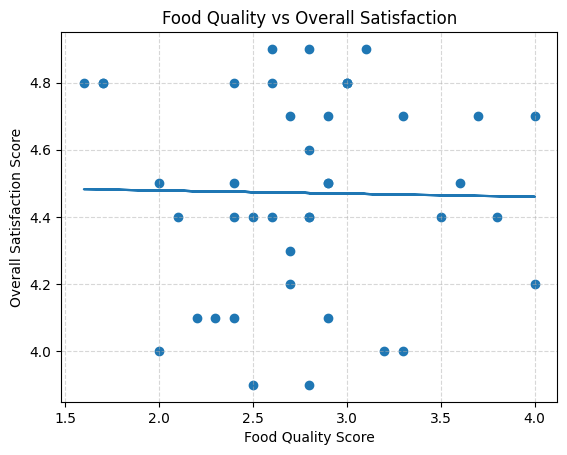

In [18]:
# Scatter plot
x = df["Avg Score (1-5)_food"]
y = df["Avg Score (1-5)_overall"]

plt.scatter(x, y)

# Add regression line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.xlabel("Food Quality Score")
plt.ylabel("Overall Satisfaction Score")
plt.title("Food Quality vs Overall Satisfaction")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

### Correlation Analysis: Food Quality and Overall Satisfaction

To explore whether food quality affects students’ overall satisfaction with their experience at the American College of Thessaloniki (ACT), I conducted a correlation analysis using the program’s student evaluation data.

Two datasets were used for this analysis:

- Overall Satisfaction scores

- Food Quality scores

Both datasets contained average student ratings on a 1–5 scale and were organized by year and academic term.

To compare the two variables, the datasets were merged using the shared columns Year and Term, ensuring that the food quality scores and overall satisfaction scores being analyzed came from the same time periods.

After merging the datasets, the score columns were converted into numeric values and any rows with missing values were removed to avoid errors during analysis. I then calculated the Pearson correlation coefficient to measure the relationship between food quality ratings and overall satisfaction ratings.

The analysis produced the following result: -0.0018

### Scatter Plot Visualization

To visually examine the relationship between food quality and overall satisfaction, a scatter plot was created. In the plot, each point represents the average scores for a specific year and academic term, with the food quality score on the x-axis and the overall satisfaction score on the y-axis.

Scatter plots are commonly used in data analysis to visualize the relationship between two numerical variables. If a relationship existed between the two variables, the points would tend to form an upward or downward pattern.

However, the points in the plot appear scattered without a clear trend or pattern. This visual result supports the correlation calculation, which found a value very close to zero.

Overall, the scatter plot reinforces the conclusion that food quality does not appear to have a strong influence on students’ overall satisfaction with their experience at ACT.

### Interpretation of Results

The correlation value of -0.018 is extremely close to zero, which indicates that there is almost no relationship between food quality ratings and overall satisfaction scores in this dataset.

This suggests that changes in food quality ratings are not strongly associated with changes in students’ overall satisfaction with the program. In other words, higher or lower food ratings do not appear to significantly influence how students rate their overall experience at ACT.

One possible explanation is that other factors may play a larger role in shaping students’ overall satisfaction. For example, aspects such as:

- Housing

- WiFi and technology access

- Safety

- Academic experiences or program activities

may have a stronger impact on how students evaluate their time at ACT.

Further analysis of these factors could help identify which areas most strongly influence overall student satisfaction.